The timothy dataset contains many minibinders and their sequences. From this dataset I created a fasta file (in another script). This fasta file has 258 minibinder sequences, evenly distributed on binders and none binders. Prediction with the tools netMHCpan_EL and netMHC_II_pan_EL was performed on this fasta file, using default settings and the human 27 allele panel.\
\
In this script the purpose is to compute the scores for each minibinder and then plot them. To see the spread of scores. Scores from the nanobody caplazicumab will be loaded and included as a reference. 

In [98]:
# load libaries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [99]:
# load data
netMHC_II_default_filterdMB = pd.read_csv("tool_outputs/filterd_timothy_netMHC_II_defaultSettings.csv")
netMHC1_default_filterdMB = pd.read_csv("tool_outputs/filterd_timothy_netMHC1_defaultSettings.csv")
seqTable_netMHC_II_default_filterdMB = pd.read_csv("tool_outputs/seqTable_filterd_timothy_netMHC_II_defaultSettings.csv")
seqTable_netMHC1_default_filterdMB = pd.read_csv("tool_outputs/seqTable_filterd_timothy_netMHC1_defaultSettings.csv")

In [100]:
# the netMHC tools do not have the antibody name in the output, only a sequence number
# Here the seq # will be mapped back to the original antibody name using the seqTable
netMHC_II_default_filterdMB = netMHC_II_default_filterdMB.merge(seqTable_netMHC_II_default_filterdMB[['seq #', 'sequence name']], how='left')
netMHC1_default_filterdMB = netMHC1_default_filterdMB.merge(seqTable_netMHC1_default_filterdMB[['seq #', 'sequence name']], how='left')

# Compute scores

In [101]:
# netMHC1
# percentile score

# Immunogenentic is defened as scored <= 1%
# Here I calculate the percantage of peptide-HLA allele combinations (rows) that have a percentile score below 1. 
netMHC_percentile = (
    netMHC1_default_filterdMB.assign(immunogenic=netMHC1_default_filterdMB['netmhcpan_el percentile'] <= 1) # flags rows where percentile is below 1
          .groupby('sequence name')['immunogenic'] # calculates mean of immunogenic for each antibody, gives the fraction
          .mean()
          .mul(100) # multiplies by 100 to get percentage
          .reset_index(name='netMHC_percentile')
    )

# immunogenicity score

# Immunogenentic is defened as scored larger than 0
# Here I calculate the percantage of peptide-HLA allele combinations (rows) that have a immunogenicity score above 0. 
netMHC_immunogenicity_score = (
    netMHC1_default_filterdMB.assign(immunogenic=netMHC1_default_filterdMB['immunogenicity score'] > 0) # flags rows where percentile is above 0
          .groupby('sequence name')['immunogenic'] # calculates mean of immunogenic for each antibody, gives the fraction
          .mean()
          .mul(100) # multiplies by 100 to get percentage
          .reset_index(name='netMHC_immunogenicity_score')
    )

# pre processing score

# Immunogenentic is not defined
# Here I simply calculate the mean score for each antibody. 
#netMCH_preProcess = netMHC1_default_filterdMB.groupby('sequence name')['processing total score'].mean().reset_index().rename(columns={'processing total score': 'netMCH_preProcess'})



# netMHC II
# percentile score

# Immunogenentic is defened as scored <= 10%
# Here I calculate the percantage of peptide-HLA allele combinations (rows) that have a percentile score below 10. 
netMHC_II_percentile = (
    netMHC_II_default_filterdMB.assign(immunogenic=netMHC_II_default_filterdMB['netmhciipan_el percentile'] <= 10) # flags rows where percentile is below 10
          .groupby('sequence name')['immunogenic'] # calculates mean of immunogenic for each antibody, gives the fraction
          .mean()
          .mul(100) # multiplies by 100 to get percentage
          .reset_index(name='netMHC_II_percentile')
    )


# Immunogenicity score

# Immunogenentic is defened as scored larger than 0
# Here I calculate the percantage of peptide-HLA allele combinations (rows) that have a immunogenicity score above 0. 
netMHC_II_immunogenicity_score = (
    netMHC_II_default_filterdMB.assign(immunogenic=netMHC_II_default_filterdMB['immunogenicity score'] > 0) # flags rows where percentile is above 0
          .groupby('sequence name')['immunogenic'] # calculates mean of immunogenic for each antibody, gives the fraction
          .mean()
          .mul(100) # multiplies by 100 to get percentage
          .reset_index(name='netMHC_II_immunogenicity_score')
    )


# Pre processing score

# mhcii-np cleavage probability

# remove the rows with the cleavage probability score of '-' before calculating the mean
netMHC_II_clean = netMHC_II_default_filterdMB[netMHC_II_default_filterdMB['mhcii-np cleavage probability score'] != '-']
# make the column with the cleavage probability score into a numeric column
netMHC_II_clean['mhcii-np cleavage probability score'] = pd.to_numeric(netMHC_II_clean['mhcii-np cleavage probability score'])
# Compute score
# Immunogenentic is not defined
# Here I simply calculate the mean score for each antibody. 
netMHC_II_preProcess_cleavProb = netMHC_II_clean.groupby('sequence name')['mhcii-np cleavage probability score'].mean().reset_index().rename(columns={'processing total score': 'netMHC_II_preProcess_cleavProb'})

# mhcii-np cleavage probability percentile rank

# remove the rows with the cleavage probability percentile rank of '-' before calculating the mean
netMHC_II_clean = netMHC_II_clean[netMHC_II_clean['mhcii-np cleavage probability percentile rank'] != '-']
# make the column with the cleavage probability percentile rank into a numeric column
netMHC_II_clean['mhcii-np cleavage probability percentile rank'] = pd.to_numeric(netMHC_II_clean['mhcii-np cleavage probability percentile rank'])
# compute score
# Immunogenentic is not defined
# Here I simply calculate the mean score for each antibody. 
netMHC_II_preProcess_cleavProbPercentile = netMHC_II_clean.groupby('sequence name')['mhcii-np cleavage probability percentile rank'].mean().reset_index().rename(columns={'mhcii-np cleavage probability percentile rank': 'netMHC_II_preProcess_cleavProbPercentile'})


C:\Users\rebbe\AppData\Local\Temp\ipykernel_18392\2159495043.py:68: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  netMHC_II_clean['mhcii-np cleavage probability score'] = pd.to_numeric(netMHC_II_clean['mhcii-np cleavage probability score'])


In [102]:
# join all scores to one df

prediction_scores = netMHC_percentile.merge(netMHC_immunogenicity_score, left_on='sequence name', right_on='sequence name', how='left').rename(columns={'sequence name': 'antibody'})
#all_predictors = all_predictors.merge(netMCH_preProcess, left_on='antibody', right_on='sequence name', how='left').drop(columns=['sequence name'])
prediction_scores = prediction_scores.merge(netMHC_II_percentile, left_on='antibody', right_on='sequence name', how='left').drop(columns=['sequence name'])
prediction_scores = prediction_scores.merge(netMHC_II_immunogenicity_score, left_on='antibody', right_on='sequence name', how='left').drop(columns=['sequence name'])
prediction_scores = prediction_scores.merge(netMHC_II_preProcess_cleavProb, left_on='antibody', right_on='sequence name', how='left').drop(columns=['sequence name'])
prediction_scores = prediction_scores.merge(netMHC_II_preProcess_cleavProbPercentile, left_on='antibody', right_on='sequence name', how='left').drop(columns=['sequence name'])

# Visualization

In [103]:
# load antibody data, so that also can be included in the plot
antibody_scores = pd.read_csv("../model_selection/Antibodies/ADA_combined_features.csv")

# add antibodies to the df with the minibinders and nanobodies
# Map them to the same column names as in all_predictors
antibody_mapped = pd.DataFrame({
    'antibody': antibody_scores['antibody'],
    'netMHC_percentile': antibody_scores['netMHC1_pep9_percentile'],
    'netMHC_immunogenicity_score': antibody_scores['netMHC1_pep9_immunogenicity_score'],
    'netMHC_II_percentile': antibody_scores['netMHC_II_pep15_percentile'],
    'netMHC_II_immunogenicity_score': antibody_scores['netMHC_II_pep15_immunogenicity_score'],
    'mhcii-np cleavage probability score': antibody_scores['mhcii_np_cleavage_probability_score'],
    'netMHC_II_preProcess_cleavProbPercentile': antibody_scores['netMHC_II_pep15_preProcess_cleavProbPercentile']
})

# Add capa df to prediction_score
prediction_scores = pd.concat([prediction_scores, antibody_mapped], ignore_index=True)

In [104]:
# load dataset with nanobodies, this is used as a reference
nanobodie_scores = pd.read_csv("../model_selection/Nanobodies/all_predictors_NB.csv")

# add nanobody to the df with the minibinders
# Map them to the same column names as in all_predictors

# maybe add later if prediciton succeeds 'netMCH_preProcess': capalizumab_scores['netMHC1_pep9_preProcess'],
nanobody_mapped = pd.DataFrame({
    'antibody': nanobodie_scores['antibody'],
    'netMHC_percentile': nanobodie_scores['netMHC1_pep9_percentile'],
    'netMHC_immunogenicity_score': nanobodie_scores['netMHC1_pep9_immunogenicity_score'],
    'netMHC_II_percentile': nanobodie_scores['netMHC_II_pep15_percentile'],
    'netMHC_II_immunogenicity_score': nanobodie_scores['netMHC_II_pep15_immunogenicity_score'],
    'mhcii-np cleavage probability score': nanobodie_scores['mhcii_np_cleavage_probability_score'],
    'netMHC_II_preProcess_cleavProbPercentile': nanobodie_scores['netMHC_II_pep15_preProcess_cleavProbPercentile']
})

# Add capa df to prediction_score
prediction_scores = pd.concat([prediction_scores, nanobody_mapped], ignore_index=True)



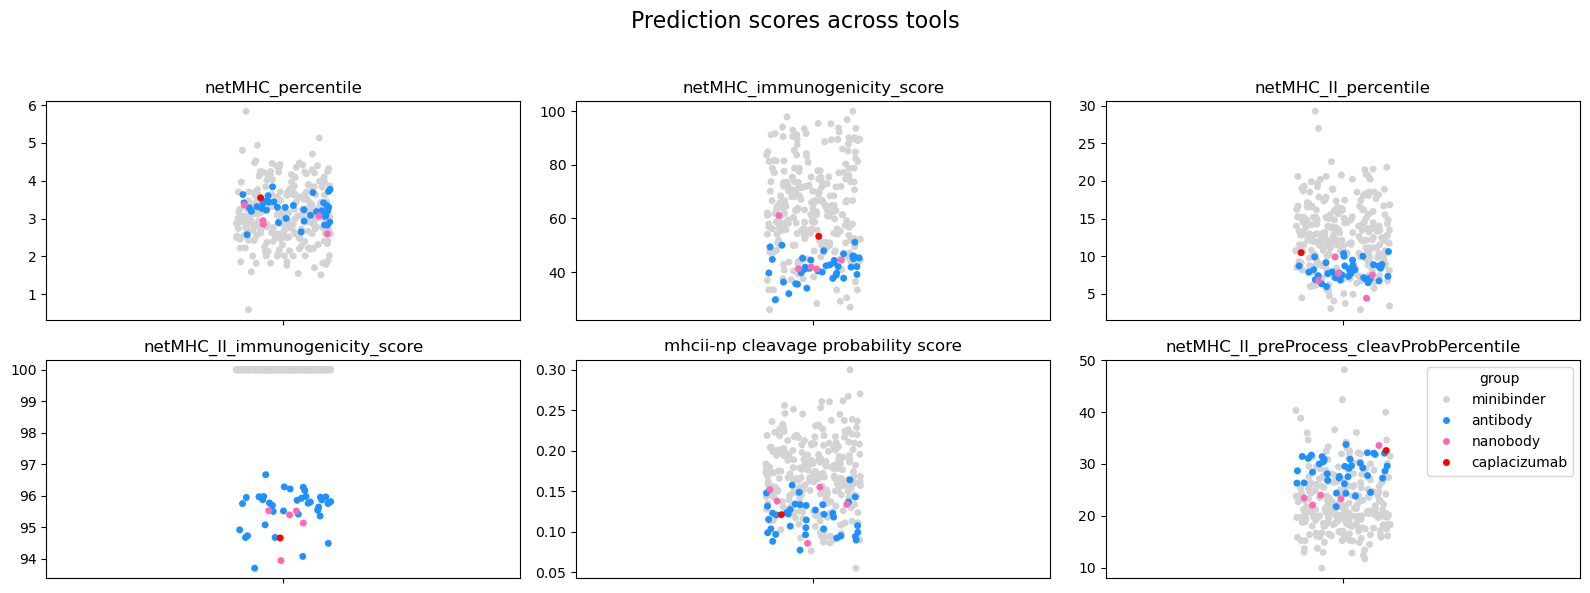

In [107]:
# create a category for coloring
prediction_scores['group'] = 'minibinder'

prediction_scores.loc[
    prediction_scores['antibody'].isin(antibody_scores['antibody']),
    'group'
] = 'antibody'

prediction_scores.loc[
    prediction_scores['antibody'].isin(nanobodie_scores['antibody']),
    'group'
] = 'nanobody'

prediction_scores.loc[
    prediction_scores['antibody'] == 'Caplacizumab',
    'group'
] = 'caplacizumab'



palette = {
    'minibinder': 'lightgray',
    'antibody': 'dodgerblue',
    'nanobody': 'hotpink',
    'caplacizumab': 'red'
}

fig, axes = plt.subplots(2, 3, figsize=(16, 6))
axes = axes.flatten()

for j, i in enumerate(range(1, 7)):
    ax = axes[j]
    col_name = prediction_scores.columns[i]
    
    sns.stripplot(
        data=prediction_scores,
        y=col_name,
        hue='group',
        palette=palette,
        ax=ax,
        dodge=False
    )
    
    ax.set_title(col_name)
    ax.set_ylabel('')
    # remove all but first legend
    if j != 5:
        ax.legend_.remove()  

# clean up legend title
#axes[0].legend(title='Group')

fig.suptitle("Prediction scores across tools", fontsize=16)

plt.tight_layout(rect=[0, 0, 1, 0.95])
# save figure
plt.savefig('scores_MB_NB_AB_tools.png')
# show figure
plt.show()

